In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

BASE     = Path('/content/drive/MyDrive/Diplom2')
META     = BASE / 'data' / 'meta'
PRE_DIR  = BASE / 'data' / 'preprocessed'
NORM_DIR = BASE / 'data' / 'normalized'
ARCH     = BASE / 'data' / 'archives'
NORM_DIR.mkdir(parents=True, exist_ok=True)
ARCH    .mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(BASE / 'code'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
meta     = pd.read_csv(META / 'meta_raw.csv')
train_df = pd.read_csv(META / 'train.csv')
val_df   = pd.read_csv(META / 'val.csv')
test_df  = pd.read_csv(META / 'test.csv')
signals  = np.load(PRE_DIR / 'signals_raw.npy', mmap_mode='r')
print('signals:', signals.shape)
print('train:', len(train_df), '| val:', len(val_df), '| test:', len(test_df))


/tmp/ipykernel_119801/650012466.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  meta     = pd.read_csv(META / 'meta_raw.csv')


signals: (92469, 2800, 12)
train: 60012 | val: 15004 | test: 17453


In [ ]:
!pip install neurokit2 wfdb -q

In [ ]:
from features import extract_features_dataset

orig_df = pd.concat([train_df, val_df, test_df], ignore_index=True).drop_duplicates('signal_idx')
basic_df, full_df = extract_features_dataset(orig_df, signals, fs=400.0, ref_lead=1, idx_col='signal_idx')

basic_df.to_csv(META / 'features_basic.csv', index=False)
full_df.to_csv(META / 'features_full.csv',  index=False)
print('basic:', basic_df.shape)
print('full: ', full_df.shape)
print('delineation failed:', int((~full_df['delineation_ok']).sum()), '/', len(full_df))


features:   0%|          | 0/92469 [00:00<?, ?it/s]

delineation failed: 637/92469 (0.7%)
basic: (92469, 49)
full:  (92469, 353)
delineation failed: 637 / 92469


In [ ]:
bad_idx = set(full_df.loc[~full_df['delineation_ok'], 'signal_idx'].astype(int).tolist())
print('bad signal_idx count:', len(bad_idx))

def _drop_bad(df):
    return df[~df['signal_idx'].astype(int).isin(bad_idx)].reset_index(drop=True)

train_df = _drop_bad(train_df)
val_df   = _drop_bad(val_df)
test_df  = _drop_bad(test_df)
print('after drop bad: train', len(train_df), 'val', len(val_df), 'test', len(test_df))


bad signal_idx count: 637
after drop bad: train 59582 val 14889 test 17361


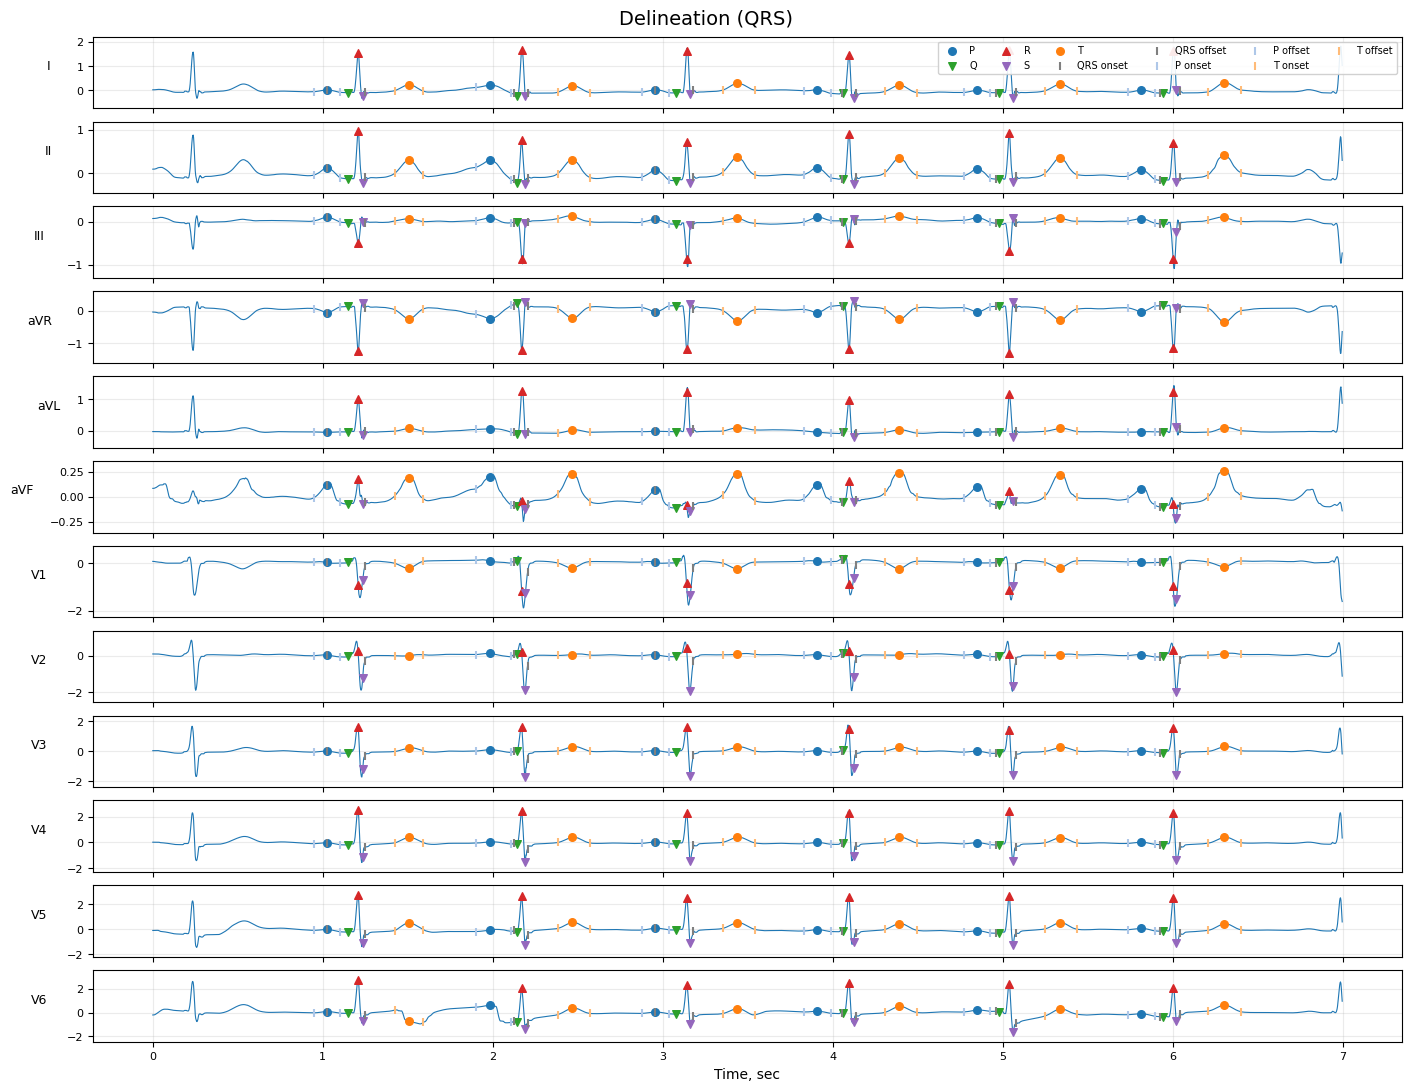

(<Figure size 1400x1080 with 12 Axes>,
 array([<Axes: ylabel='I'>, <Axes: ylabel='II'>, <Axes: ylabel='III'>,
        <Axes: ylabel='aVR'>, <Axes: ylabel='aVL'>, <Axes: ylabel='aVF'>,
        <Axes: ylabel='V1'>, <Axes: ylabel='V2'>, <Axes: ylabel='V3'>,
        <Axes: ylabel='V4'>, <Axes: ylabel='V5'>,
        <Axes: xlabel='Time, sec', ylabel='V6'>], dtype=object))

In [ ]:
from features import delineate
from plot import plot_ecg

demo_si = int(train_df.iloc[0]['signal_idx'])
demo_sig = np.array(signals[demo_si])
demo_peaks = delineate(demo_sig, fs=400)
plot_ecg(demo_sig, peaks=demo_peaks, fs=400, title='Delineation (QRS)')


In [ ]:
feats_ok = full_df[full_df['delineation_ok']].drop(columns=['delineation_ok']).copy()
feats_ok['signal_idx'] = feats_ok['signal_idx'].astype(int)

for df in (train_df, val_df, test_df):
    df['signal_idx'] = df['signal_idx'].astype(int)

train_df = train_df.merge(feats_ok, on='signal_idx', how='inner')
val_df   = val_df  .merge(feats_ok, on='signal_idx', how='inner')
test_df  = test_df .merge(feats_ok, on='signal_idx', how='inner')
print('after feature merge: train', len(train_df), 'val', len(val_df), 'test', len(test_df))


after feature merge: train 59582 val 14889 test 17361


In [ ]:
df = (
    pd.concat([train_df, val_df, test_df], ignore_index=True)
    .drop_duplicates('signal_idx')
    .reset_index(drop=True)
)

samitrop_pos = df[(df['dataset_group'] == 'samitrop') & (df['chagas_label'] == 1)]
code15_pos   = df[(df['dataset_group'] == 'code15')   & (df['chagas_label'] == 1)]
neg          = df[df['chagas_label'] == 0]

assert len(samitrop_pos) >= 300, len(samitrop_pos)

test_samitrop_idx = samitrop_pos.sample(n=300,     random_state=42).index
test_code15_idx = code15_pos  .sample(frac=0.15, random_state=42).index
test_neg_idx = neg          .sample(frac=0.20, random_state=42).index
test_idx = test_samitrop_idx.union(test_code15_idx).union(test_neg_idx)

remaining = df.drop(index=test_idx)
remaining_pos = remaining[remaining['chagas_label'] == 1]
remaining_neg = remaining[remaining['chagas_label'] == 0]

val_pos_idx = remaining_pos.sample(frac=0.20, random_state=42).index
val_neg_idx = remaining_neg.sample(frac=0.20, random_state=42).index
val_idx = val_pos_idx.union(val_neg_idx)
train_idx = remaining.drop(index=val_idx).index

train_df = df.loc[train_idx].assign(split='train').reset_index(drop=True)
val_df = df.loc[val_idx  ].assign(split='val'  ).reset_index(drop=True)
test_df = df.loc[test_idx ].assign(split='test' ).reset_index(drop=True)

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{name}: {len(part)} | pos={int((part['chagas_label']==1).sum())} neg={int((part['chagas_label']==0).sum())}")

train_df.to_csv(META / 'train.csv', index=False)
val_df  .to_csv(META / 'val.csv',   index=False)
test_df .to_csv(META / 'test.csv',  index=False)


train: 59009 | pos=5025 neg=53984
val: 14752 | pos=1256 neg=13496
test: 18071 | pos=1201 neg=16870


In [ ]:
from preprocessing import augment_ecg
from simvea import simvea_h_augment

def aug_fn(sig_TC):
    a = augment_ecg(sig_TC.copy())
    a = simvea_h_augment(a.T, p=1.0).T
    return a.astype(np.float32)

N_AUG     = {'samitrop': 10, 'code15': 5}
train_pos = train_df[train_df['chagas_label'] == 1]

n_aug_total = sum(N_AUG.get(r['dataset_group'], 5) for _, r in train_pos.iterrows())
print('aug rows planned:', n_aug_total)

aug_path = PRE_DIR / 'signals_aug.npy'
aug_memmap = np.lib.format.open_memmap(
    str(aug_path), mode='w+', dtype=np.float32, shape=(n_aug_total, 2800, 12)
)

rng, aug_rows, wi = np.random.default_rng(42), [], 0
for _, row in tqdm(train_pos.iterrows(), total=len(train_pos), desc='augment'):
    sig = np.array(signals[int(row['signal_idx'])]).astype(np.float32)
    for _ in range(N_AUG.get(row['dataset_group'], 5)):
        np.random.seed(int(rng.integers(0, 2**31 - 1)))
        aug_memmap[wi] = aug_fn(sig)
        aug_rows.append(row.to_dict())
        wi += 1

aug_memmap.flush()
del aug_memmap

aug_meta_df = pd.DataFrame(aug_rows).reset_index(drop=True)
aug_meta_df['aug_idx'] = np.arange(len(aug_meta_df))
print('augmented file written:', aug_path)


aug rows planned: 29930


augment:   0%|          | 0/5025 [00:00<?, ?it/s]

augmented file written: /content/drive/MyDrive/Diplom2/data/preprocessed/signals_aug.npy


In [ ]:
aug_signals = np.load(aug_path, mmap_mode='r')

basic_aug, full_aug = extract_features_dataset(
    aug_meta_df, aug_signals, fs=400.0, ref_lead=1, idx_col='aug_idx'
)
basic_aug.to_csv(META / 'features_basic_aug.csv', index=False)
full_aug .to_csv(META / 'features_full_aug.csv',  index=False)
print('aug basic:', basic_aug.shape, '| aug full:', full_aug.shape)
print('aug delineation failed:', int((~full_aug['delineation_ok']).sum()), '/', len(full_aug))


features:   0%|          | 0/29930 [00:00<?, ?it/s]

delineation failed: 3/29930 (0.0%)
aug basic: (29930, 49) | aug full: (29930, 353)
aug delineation failed: 3 / 29930


In [ ]:
basic_df ['is_augmented'] = False
full_df  ['is_augmented'] = False
basic_aug['is_augmented'] = True
full_aug ['is_augmented'] = True

basic_all = pd.concat([basic_df, basic_aug], ignore_index=True)
full_all  = pd.concat([full_df,  full_aug ], ignore_index=True)

basic_all.to_csv(META / 'features_basic_all.csv', index=False)
full_all .to_csv(META / 'features_full_all.csv',  index=False)
print('basic_all:', basic_all.shape, '| full_all:', full_all.shape)


basic_all: (122399, 50) | full_all: (122399, 354)


In [ ]:
n_orig = signals.shape[0]
n_aug  = aug_signals.shape[0]
merged_path = PRE_DIR / 'signals_merged.npy'

merged = np.lib.format.open_memmap(
    str(merged_path), mode='w+', dtype=np.float32, shape=(n_orig + n_aug, 2800, 12)
)

CHUNK = 1024
for i in tqdm(range(0, n_orig, CHUNK), desc='copy orig'):
    j = min(i + CHUNK, n_orig)
    merged[i:j] = signals[i:j]
for i in tqdm(range(0, n_aug, CHUNK), desc='copy aug'):
    j = min(i + CHUNK, n_aug)
    merged[n_orig + i : n_orig + j] = aug_signals[i:j]

merged.flush()
del merged
print('merged signals written:', merged_path)

aug_meta_df['signal_idx'] = np.arange(n_orig, n_orig + n_aug)
train_df_aug = pd.concat([train_df, aug_meta_df], ignore_index=True)
print('train_df_aug:', len(train_df_aug), '| orig:', len(train_df), '| aug:', len(aug_meta_df))


In [ ]:
from preprocessing import build_normalized, make_archive

norm_meta, mean_c, std_c = build_normalized(
    train_df_aug, val_df, test_df,
    src_signals_path=merged_path,
    dst_signals_path=NORM_DIR / 'signals_norm.npy',
    dst_meta_path=META / 'meta_norm.csv',
    stats_path=META / 'stats.npz',
    augment_fn=None,
    src_idx_col='signal_idx',
    seed=42,
)
print('norm signals saved, total rows:', len(norm_meta))
print('archive size:', make_archive(NORM_DIR / 'signals_norm.npy', ARCH / 'normalized.tar'))


train stats:   0%|          | 0/88939 [00:00<?, ?it/s]

train:   0%|          | 0/88939 [00:00<?, ?it/s]

val:   0%|          | 0/14752 [00:00<?, ?it/s]

test:   0%|          | 0/18071 [00:00<?, ?it/s]

norm signals saved, total rows: 121762
archive size: 16364820480


In [ ]:
from splits import select_feature_cols

technical_cols = {'fs_hz', 'n_samples', 'duration_sec', 'n_leads', 'has_standard_12_leads'}

feature_cols_full = [
    c for c in select_feature_cols(train_df)
    if c not in technical_cols
]
print('feature_cols before VIF:', len(feature_cols_full))


feature_cols before VIF: 353


In [ ]:
feature_cols_full

['age',
 'sex_code',
 'I_mean',
 'I_std',
 'I_rms',
 'I_ptp',
 'II_mean',
 'II_std',
 'II_rms',
 'II_ptp',
 'III_mean',
 'III_std',
 'III_rms',
 'III_ptp',
 'aVR_mean',
 'aVR_std',
 'aVR_rms',
 'aVR_ptp',
 'aVL_mean',
 'aVL_std',
 'aVL_rms',
 'aVL_ptp',
 'aVF_mean',
 'aVF_std',
 'aVF_rms',
 'aVF_ptp',
 'V1_mean',
 'V1_std',
 'V1_rms',
 'V1_ptp',
 'V2_mean',
 'V2_std',
 'V2_rms',
 'V2_ptp',
 'V3_mean',
 'V3_std',
 'V3_rms',
 'V3_ptp',
 'V4_mean',
 'V4_std',
 'V4_rms',
 'V4_ptp',
 'V5_mean',
 'V5_std',
 'V5_rms',
 'V5_ptp',
 'V6_mean',
 'V6_std',
 'V6_rms',
 'V6_ptp',
 'QRS_duration_min',
 'QRS_duration_max',
 'QRS_duration_avg',
 'PR_interval_min',
 'PR_interval_max',
 'PR_interval_avg',
 'QT_interval_min',
 'QT_interval_max',
 'QT_interval_avg',
 'P_duration_min',
 'P_duration_max',
 'P_duration_avg',
 'T_duration_min',
 'T_duration_max',
 'T_duration_avg',
 'R_amp_I_min',
 'R_amp_I_max',
 'R_amp_I_avg',
 'Q_amp_I_min',
 'Q_amp_I_max',
 'Q_amp_I_avg',
 'S_amp_I_min',
 'S_amp_I_max',
 '

In [ ]:
from sklearn.utils import resample

def vif_select(df, cols, threshold=50.0, sample_n=3000, random_state=42):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    cols = list(cols)
    while True:
        sample = resample(df[cols], n_samples=min(sample_n, len(df)),
                          random_state=random_state, replace=False)
        sample = sample.replace([np.inf, -np.inf], np.nan).fillna(sample.median(numeric_only=True))
        Xc   = add_constant(sample, has_constant='add')
        vifs = [variance_inflation_factor(Xc.values, i + 1) for i in range(len(cols))]
        worst = int(np.nanargmax(vifs))
        if not np.isfinite(vifs[worst]) or vifs[worst] > threshold:
            cols.pop(worst)
            if not cols:
                break
        else:
            break
    return cols

kept_cols = vif_select(train_df, feature_cols_full)
print('VIF kept:', len(kept_cols))
pd.Series(kept_cols).to_csv(META / 'feature_cols.csv', index=False, header=['feature'])
print('saved feature_cols.csv')


VIF kept: 205
saved feature_cols.csv
